<h2>Importing libaries</h2>

In [1]:
import pickle # save and load python objects
import json # stores and reads data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # builds untop a matplotlib and maks certain statistical plot easier

import tensorflow as tf 
from tensorflow import keras

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

tf.random.set_seed(42)
np.random.seed(42)  # seed mean random numbers that don't change each time you run the code 

<h3>Load and split data</h3>

In [2]:
train_df=pd.read_csv('heart_disease_train.csv')
test_df=pd.read_csv('heart_disease_test.csv')
val_df=pd.read_csv('heart_disease_val.csv')

X_train=train_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
Y_train=train_df['Heart_Disease'].values.astype(np.float32)

X_test=test_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
Y_test=test_df['Heart_Disease'].values.astype(np.float32)

X_val=val_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
Y_val=val_df['Heart_Disease'].values.astype(np.float32)

print(f"Train : {X_train.shape}")
print(f"Test : {X_test.shape}")
print(f"Val : {X_val.shape}")
print(f"Number of Features : {X_train.shape[1]}")

Train : (18627, 16)
Test : (5979, 16)
Val : (5285, 16)
Number of Features : 16


LOAD METADATA

In [7]:
with open("heart_disease_metadata.json") as f:
    metadata = json.load(f) # metadata: info that describes the data. converting the data into  a dictionary formate

Features = metadata['feature_cols']
scaler_mean = np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f"Loaded metadat for {len(Features)} Features")

scaler_scale

Loaded metadat for 16 Features


array([14.490715  ,  0.49998444,  6.3466773 ,  0.7975433 ,  0.74745375,
        0.8748711 ,  0.8941631 ,  0.45809102,  0.4003057 ,  0.43613592,
        0.4909653 ,  0.2991607 , 23.09571   , 17.249577  , 31.678753  ,
       43.04224   ], dtype=float32)

BUILD ARCHITECTURE

In [9]:
def build_ann(Features):
    inputs = keras.Input(shape=(Features,), name='Features')


    
    # block 1
    x = keras.layers.Dense(128, kernel_regularizer= keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    # block 2
    x = keras.layers.Dense(32)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    #block 3
    x = keras.layers.Dense(32)(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    #output: a single probability
    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)
    return keras.models.Model(inputs, outputs, name='Heart_DiseaseANN')

model = build_ann(X_train.shape[1])
model.summary()

Model: "Heart_DiseaseANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Features (InputLayer)                │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,033 (31.38 KB)

 Trainable params: 7,713 (30.13 KB)

 Non-trainable params: 320 (1.25 KB)

COMPILE MODEL

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

TRAIN WITH CALLBACKS

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', varbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_heart_disease.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0),
]

history = model.fit(
    X_train, Y_train,
    epochs=300, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run: (len(history.history['loss']))")
print(f"Best val AUC: {max(history.history['val_auc']):.4f}")

Epoch 1/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8154 - auc: 0.9044 - loss: 0.3932 - precision: 0.8201 - recall: 0.7712 - val_accuracy: 0.9215 - val_auc: 0.9820 - val_loss: 0.1857 - val_precision: 0.9050 - val_recall: 0.9282 - learning_rate: 5.0000e-04
Epoch 2/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8975 - auc: 0.9644 - loss: 0.2437 - precision: 0.8890 - recall: 0.8901 - val_accuracy: 0.9309 - val_auc: 0.9847 - val_loss: 0.1674 - val_precision: 0.9166 - val_recall: 0.9364 - learning_rate: 5.0000e-04
Epoch 3/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9066 - auc: 0.9697 - loss: 0.2245 - precision: 0.8969 - recall: 0.9023 - val_accuracy: 0.9328 - val_auc: 0.9866 - val_loss: 0.1584 - val_precision: 0.9162 - val_recall: 0.9413 - learning_rate: 5.0000e-04
Epoch 4/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9100 - auc: 0.9724 - loss: 0.2149 - precision: 0.8983 - recall: 0.9088 - val_accuracy: 0.9372 - val_auc: 0.9881 - val_lo

VISUALIZE HISTORY

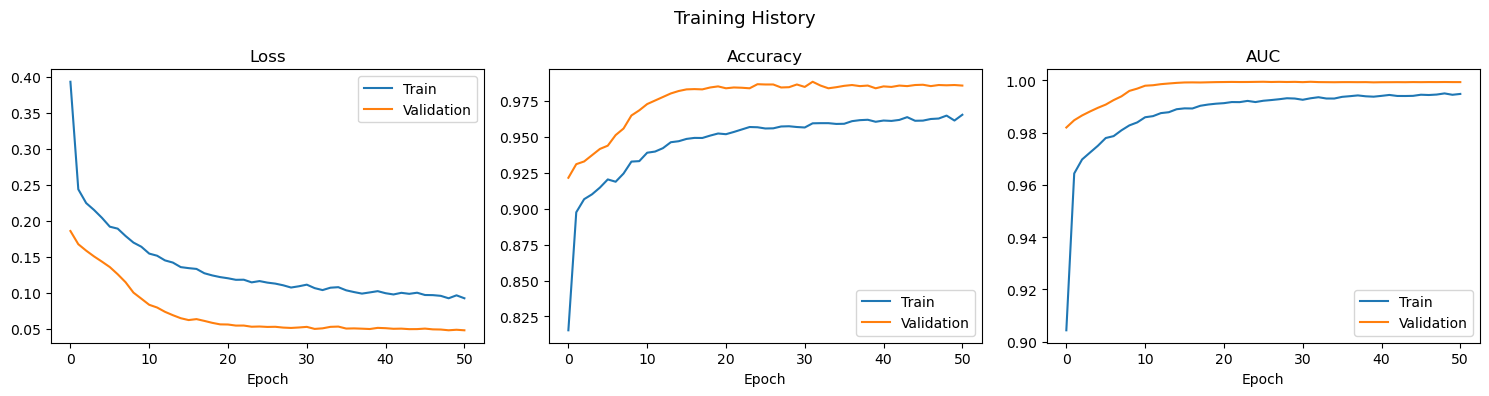

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('heart_disease.png', dpi=150, bbox_inches='tight')
plt.show()

EVALUATE ON TEST SET

In [15]:
model.load_weights('best_heart_disease.keras')

test_results = model.evaluate(X_test, Y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.3f}")

loss        : 0.054
compile_metrics: 0.987


ROCK AND AUC CURVE

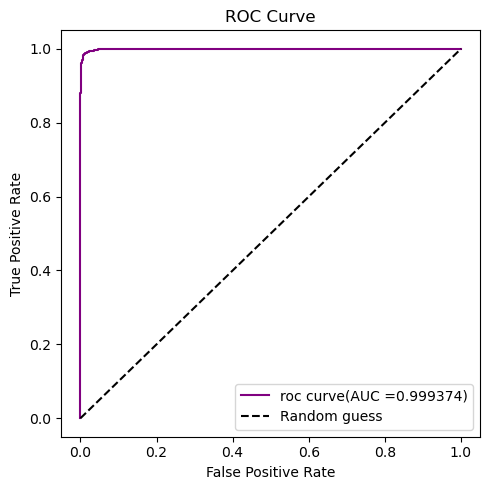

ROC-AUC: 0.9994


In [17]:
Y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(Y_test, Y_prob)

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='purple', label=f'roc curve(AUC ={auc_score:2f})')
plt.plot([0,1],[0,1], color='black', linestyle='--', label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

CLASSIFICATION REPORT

                  precision    recall  f1-score   support

No Heart_Disease       0.99      0.98      0.99      3205
   Heart_Disease       0.98      0.99      0.99      2774

        accuracy                           0.99      5979
       macro avg       0.99      0.99      0.99      5979
    weighted avg       0.99      0.99      0.99      5979



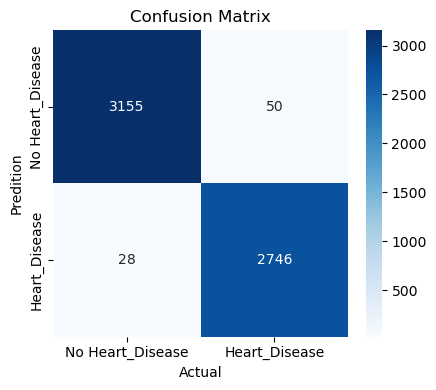

In [18]:
Y_pred = (Y_prob >= 0.5).astype(int)
import seaborn as sns

print(classification_report(Y_test, Y_pred, target_names=['No Heart_Disease', 'Heart_Disease']))

cm=confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Heart_Disease', 'Heart_Disease'],
           yticklabels=['No Heart_Disease', 'Heart_Disease'])
plt.xlabel('Actual')
plt.ylabel('Predition')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


SAVE MODEL

In [19]:
model.save('heart_disease_ann.keras')

with open('heart_disease_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_scale,
        'Features': Features,
    }, f)

print("Saved heart_disease_ann.keras")
print("Saved heart_disease_inference_kit.pkl")

Saved heart_disease_ann.keras
Saved heart_disease_inference_kit.pkl
